In [1]:
import pandas as pd
import numpy as np
import yfinance as yf
import statsmodels.api as sm
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
start_date = "2013-01-01"
end_date = "2026-05-06"
# XLK    0.865315
# XLI    0.692094
# XLV    0.686735
# XLP    0.643245
# XLY    0.637429
# XLU    0.577137
# XLF    0.566613
# XLB    0.477754
# XLE    0.261838
sector_universe = [
    "XLK",  # Information Technology
    "XLI",  # Industrials
    "XLV",  # Health Care
    "XLP",  # Consumer Staples
    "XLC",  # Communication Services
    "XLY",  # Consumer Discretionary
    "XLE",  # Energy
    "XLF",  # Financials
    "XLB",  # Materials
    "XLRE",  # Real Estate
    "XLU",  # Utilities
    "TLT",
    "GLD",
    "VIXY",
    "IEF",
    "EDV",
]

In [33]:
spy_data = yf.download("SPY", start=start_date, end=end_date)
spy_close = spy_data["Close"].dropna(axis=1)
spy_returns_df = spy_close.pct_change().fillna(0)
spy_log_ret_df = np.log(spy_close / spy_close.shift(1))

[*********************100%***********************]  1 of 1 completed


In [29]:
data = yf.download(sector_universe, start=start_date, end=end_date)
close_df = data["Close"].dropna(axis=1)
volume_df = data["Volume"].dropna(axis=1)
returns_df = close_df.pct_change().fillna(0)
log_returns_df = np.log(close_df / close_df.shift(1))

[*********************100%***********************]  16 of 16 completed


<Axes: xlabel='Date'>

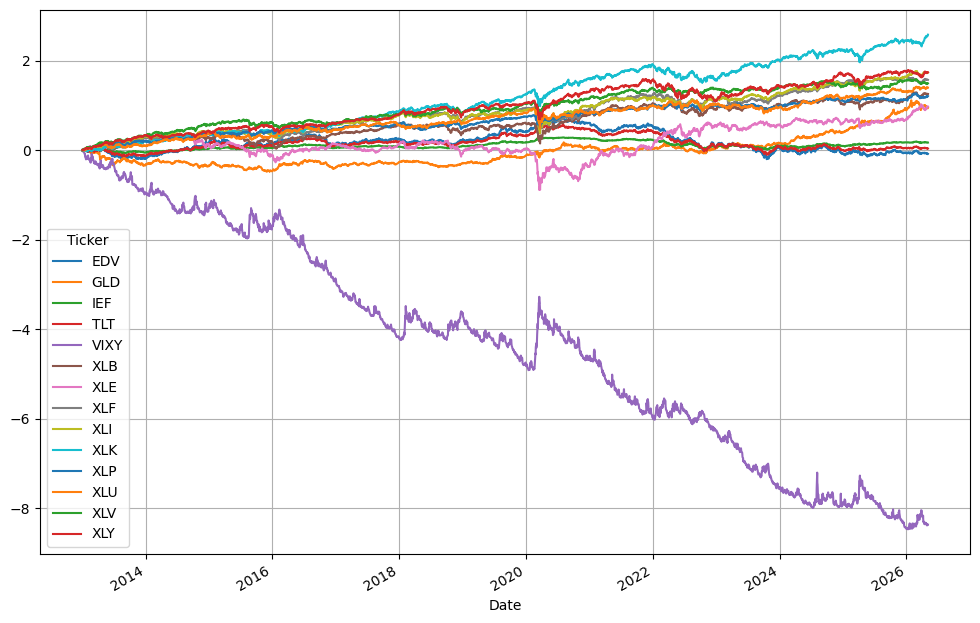

In [30]:
log_returns_df.cumsum().plot(grid=True, figsize=(12, 8))

In [31]:
(log_returns_df.mean(axis=0) / log_returns_df.std(axis=0) * np.sqrt(252)).sort_values(
    ascending=False
)

Ticker
XLK     0.865315
XLI     0.692094
XLV     0.686735
XLP     0.643245
XLY     0.637429
XLU     0.577137
XLF     0.566613
XLB     0.477754
GLD     0.432370
XLE     0.261838
IEF     0.192663
TLT     0.017306
EDV    -0.032204
VIXY   -0.925379
dtype: float64

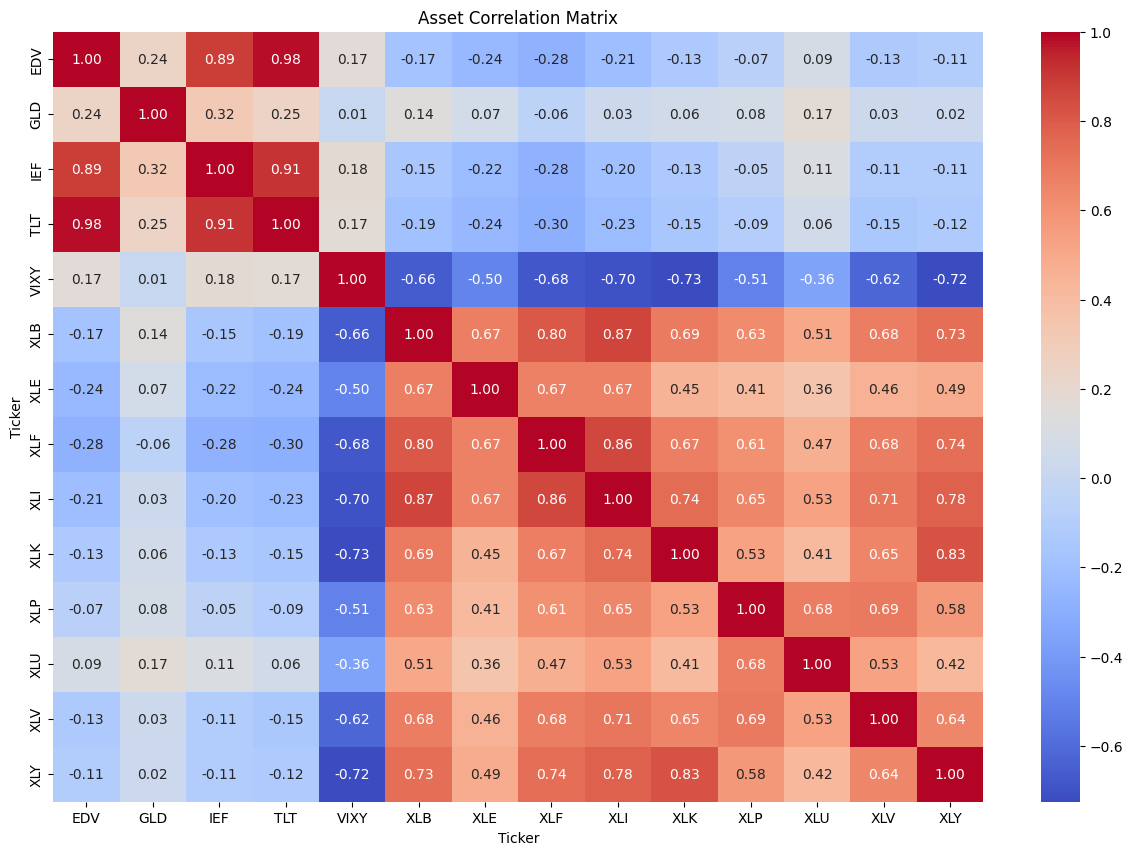

In [32]:
log_returns_df = np.log(close_df / close_df.shift(1)).dropna()
corr_matrix = log_returns_df.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [38]:
common_index = log_returns_df.index.intersection(spy_log_ret_df.index)
ret = log_returns_df.loc[common_index]
spy_ret = spy_log_ret_df.loc[common_index]

X = sm.add_constant(spy_ret.squeeze())
residuals_df = pd.DataFrame(index=ret.index, columns=ret.columns)

for ticker in returns_df.columns:
    Y = returns_df[ticker]
    model = sm.OLS(Y, X, missing="drop").fit()
    residuals_df[ticker] = model.resid

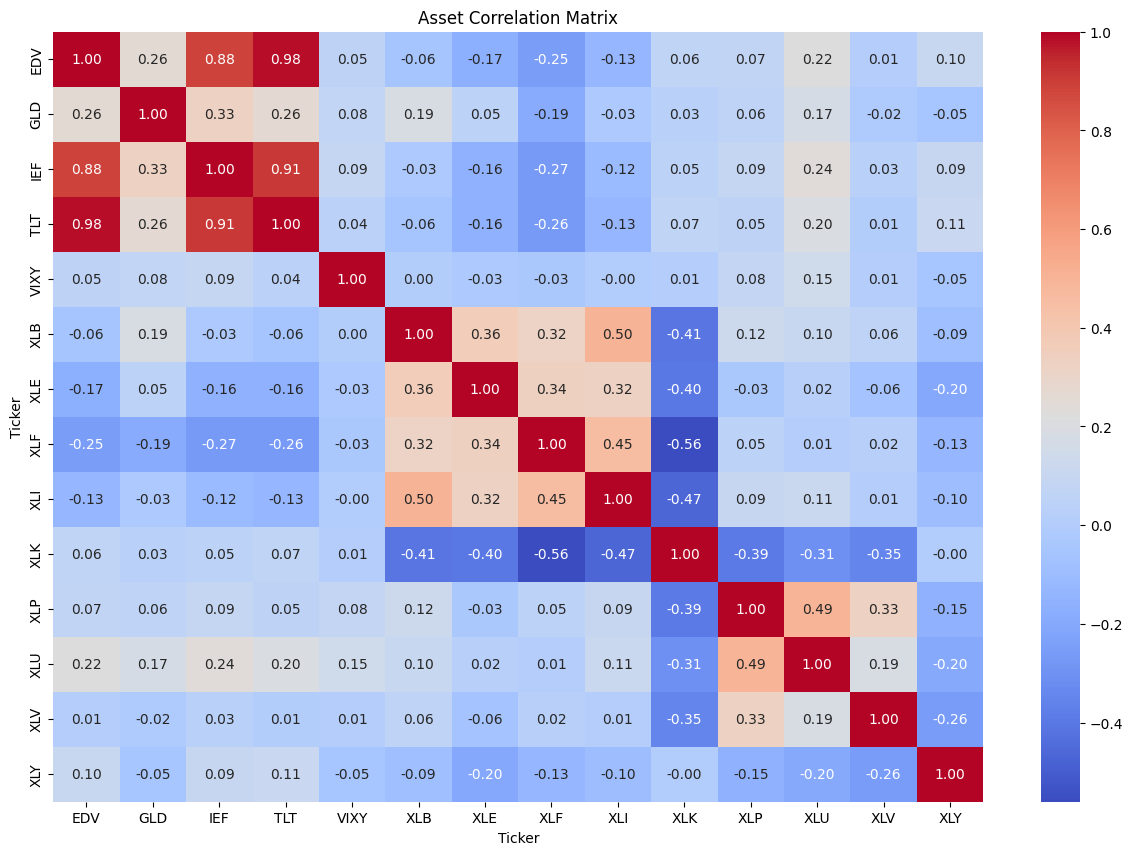

In [40]:
corr_matrix = residuals_df.corr()

# Plotting the Heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Asset Correlation Matrix")
plt.show()

In [42]:
opt_ch = pd.read_csv(
    "/Users/jplatta/.tickrake/data/options/schwab/2026/05/07/SPXW_exp2026-05-07_2026-05-07_14-46-43.csv",
    header=0,
)

In [60]:
opt_ch.columns

Index(['contract_type', 'symbol', 'description', 'strike', 'expiration_date',
       'open', 'high', 'low', 'close', 'mark', 'bid', 'bid_size', 'ask',
       'ask_size', 'last', 'last_size', 'open_interest', 'total_volume',
       'transactions', 'delta', 'gamma', 'theta', 'vega', 'rho', 'volatility',
       'theoretical_volatility', 'theoretical_option_value', 'intrinsic_value',
       'extrinsic_value', 'underlying_price'],
      dtype='object')

In [61]:
calls = opt_ch.loc[
    opt_ch["contract_type"] == "CALL", ["delta", "strike", "contract_type", "mark", "volatility"]
]
puts = opt_ch.loc[
    opt_ch["contract_type"] == "PUT", ["delta", "strike", "contract_type", "mark", "volatility"]
]

In [62]:
list(calls["delta"])

[1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 1.0,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.999,
 0.998,
 0.998,
 0.998,
 0.998,
 0

In [63]:
calls.loc[(calls["delta"] >= 0.24) & (calls["delta"] <= 0.27)]

,delta,strike,contract_type,mark,volatility
213,0.241,7395.0,CALL,3.35,12.987


In [64]:
puts.loc[(puts["delta"].abs() >= 0.24) & (puts["delta"].abs() <= 0.27)]

,delta,strike,contract_type,mark,volatility
486,-0.253,7360.0,PUT,4.15,14.85
